# 02 — Exploratory Analysis & Visualizations
**Scientific question:** *Is the relationship between CO₂ emissions and surface temperature warming uniform across world regions, or do some regions warm faster despite emitting less?*


## 1. Imports & Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.3f}'.format)

BASE = '/kaggle/input/datasets/maryemteyeb/01-preprocessing-output/'

owid      = pd.read_csv(BASE + 'owid_clean.csv')
nasa      = pd.read_csv(BASE + 'nasa_clean.csv')
sea       = pd.read_csv(BASE + 'sea_clean.csv')
disasters = pd.read_csv(BASE + 'disasters_clean.csv')
global_df = pd.read_csv(BASE + 'global_merged.csv')

latest_year = int(owid['Year'].max())
print(f'All datasets loaded ✓  |  Latest year in OWID: {latest_year}')

All datasets loaded ✓  |  Latest year in OWID: 2024


---
## 2. Global CO₂ Emissions Over Time

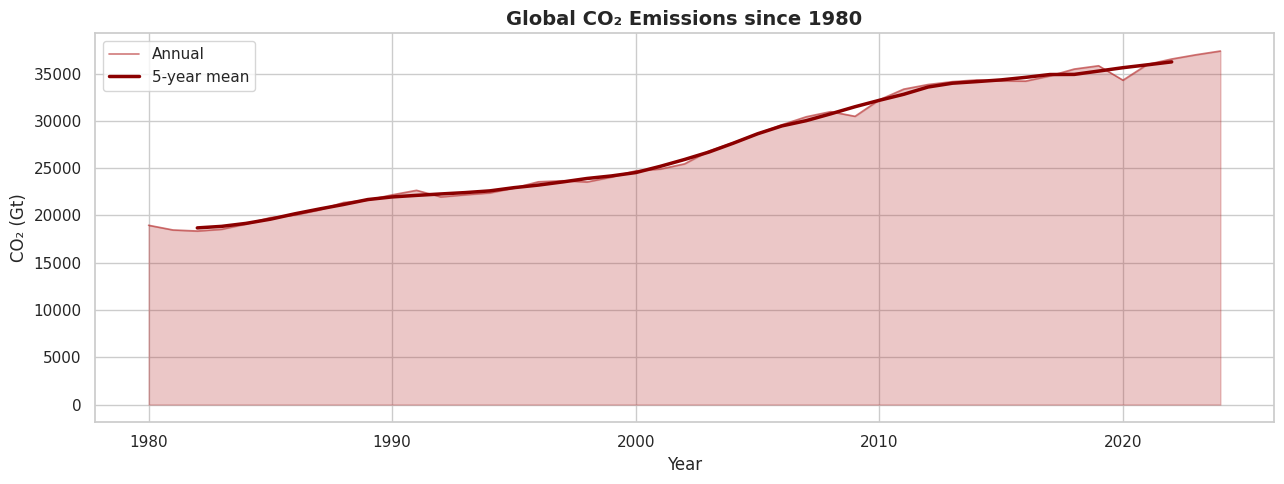

Global CO₂ growth since 1980: +97.2%


In [2]:
global_co2 = owid.groupby('Year')['co2'].sum().reset_index()
global_co2['co2_5yr'] = global_co2['co2'].rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(global_co2['Year'], global_co2['co2'], alpha=0.25, color='firebrick')
ax.plot(global_co2['Year'], global_co2['co2'], color='firebrick', linewidth=1.2, alpha=0.6, label='Annual')
ax.plot(global_co2['Year'], global_co2['co2_5yr'], color='darkred', linewidth=2.5, label='5-year mean')
ax.set_title('Global CO₂ Emissions since 1980', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (Gt)')
ax.legend()
plt.tight_layout()
plt.show()

total_growth = ((global_co2['co2'].iloc[-1] - global_co2['co2'].iloc[0]) / global_co2['co2'].iloc[0] * 100)
print(f'Global CO₂ growth since 1980: +{total_growth:.1f}%')

---
## 3. Temperature Anomaly — Global Warming Trend

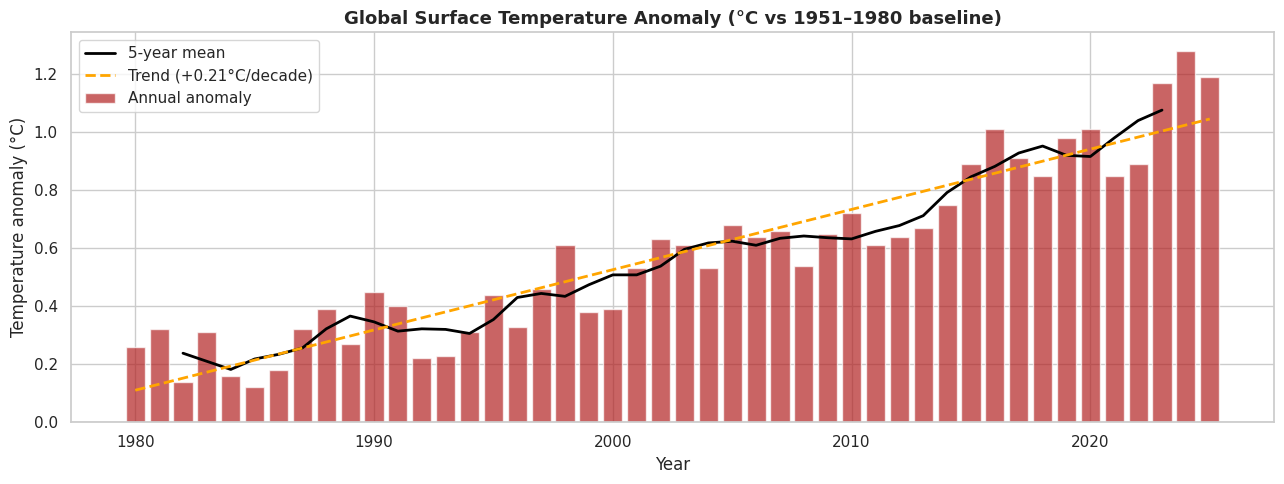

Warming trend: +0.208°C per decade  |  R²=0.872  |  p=3.10e-21
Warmest year: 2024 (1.28°C above baseline)


In [3]:
nasa['temp_5yr'] = nasa['temp_anomaly'].rolling(5, center=True).mean()
slope, intercept, r, p, _ = stats.linregress(nasa['Year'], nasa['temp_anomaly'])
nasa['trend'] = slope * nasa['Year'] + intercept

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(nasa['Year'], nasa['temp_anomaly'],
       color=['firebrick' if x > 0 else 'steelblue' for x in nasa['temp_anomaly']],
       alpha=0.7, label='Annual anomaly')
ax.plot(nasa['Year'], nasa['temp_5yr'], color='black', linewidth=2, label='5-year mean')
ax.plot(nasa['Year'], nasa['trend'], color='orange', linewidth=2, linestyle='--',
        label=f'Trend (+{slope*10:.2f}°C/decade)')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Global Surface Temperature Anomaly (°C vs 1951–1980 baseline)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Temperature anomaly (°C)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Warming trend: +{slope*10:.3f}°C per decade  |  R²={r**2:.3f}  |  p={p:.2e}')
print(f'Warmest year: {nasa.loc[nasa["temp_anomaly"].idxmax(), "Year"]:.0f} ({nasa["temp_anomaly"].max():.2f}°C above baseline)')

---
## 4. Sea Level Rise

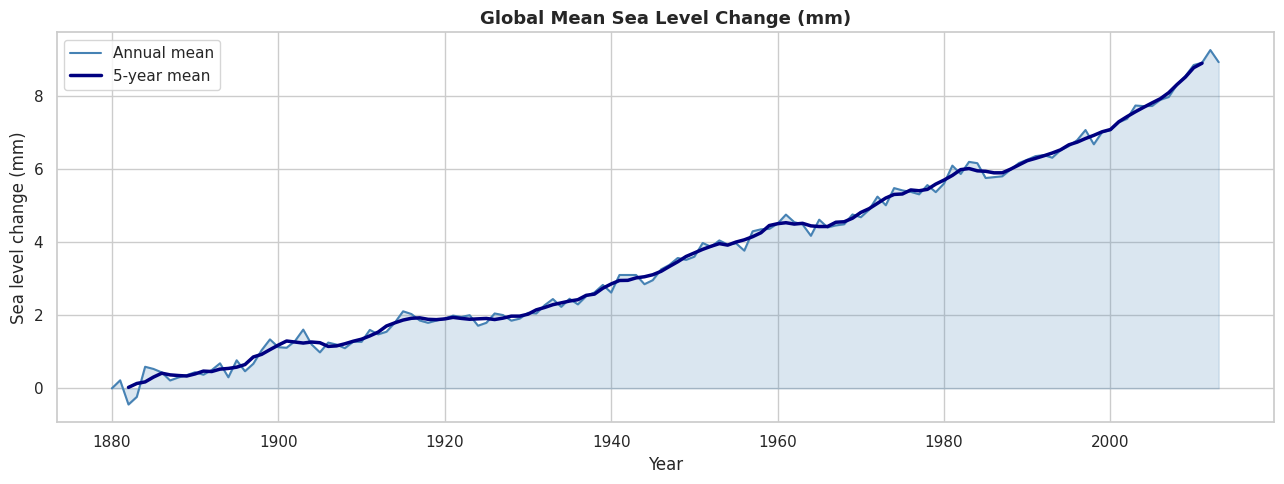

Total sea level rise in dataset: 9.7 mm
Average rise rate: +0.06 mm/year


In [4]:
sea['slr_5yr'] = sea['sea_level_mm'].rolling(5, center=True).mean()
slope_sea, intercept_sea, _, _, _ = stats.linregress(
    sea.dropna(subset=['sea_level_mm'])['Year'],
    sea.dropna(subset=['sea_level_mm'])['sea_level_mm']
)

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(sea['Year'], sea['sea_level_mm'], alpha=0.2, color='steelblue')
ax.plot(sea['Year'], sea['sea_level_mm'], color='steelblue', linewidth=1.5, label='Annual mean')
ax.plot(sea['Year'], sea['slr_5yr'], color='navy', linewidth=2.5, label='5-year mean')
ax.set_title('Global Mean Sea Level Change (mm)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Sea level change (mm)')
ax.legend()
plt.tight_layout()
plt.show()

total_rise = sea['sea_level_mm'].max() - sea['sea_level_mm'].min()
print(f'Total sea level rise in dataset: {total_rise:.1f} mm')
print(f'Average rise rate: +{slope_sea:.2f} mm/year')

---
## 5. Natural Disasters Frequency

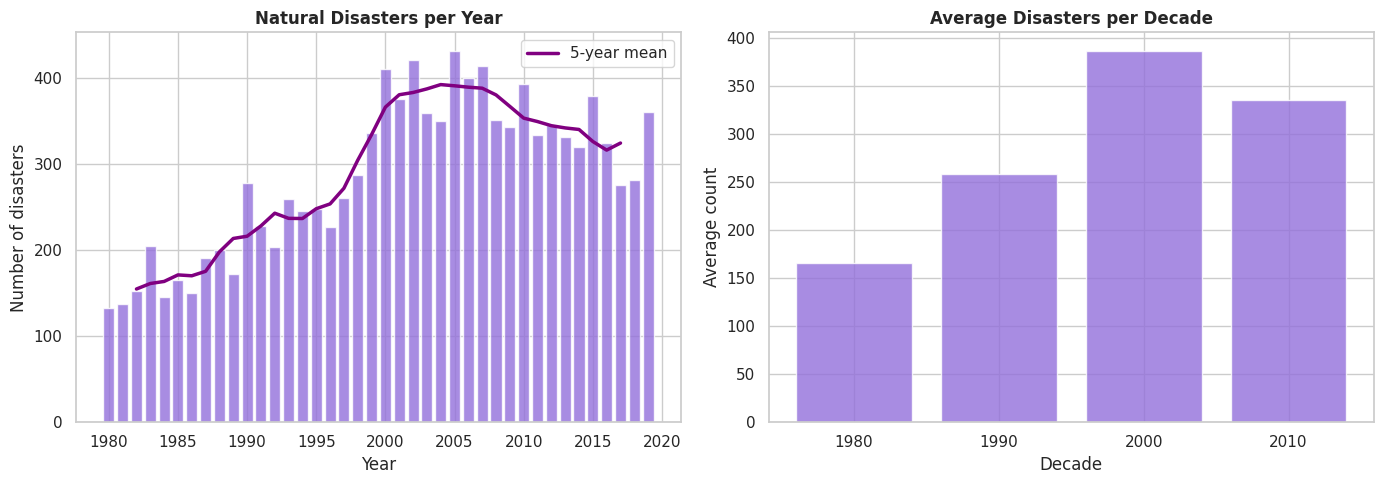

In [5]:
disasters['decade'] = (disasters['Year'] // 10) * 10
decade_avg = disasters.groupby('decade')['n_disasters'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(disasters['Year'], disasters['n_disasters'], color='mediumpurple', alpha=0.8)
axes[0].plot(disasters['Year'],
             disasters['n_disasters'].rolling(5, center=True).mean(),
             color='purple', linewidth=2.5, label='5-year mean')
axes[0].set_title('Natural Disasters per Year', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of disasters')
axes[0].legend()

axes[1].bar(decade_avg['decade'].astype(str), decade_avg['n_disasters'],
            color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1].set_title('Average Disasters per Decade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Average count')

plt.tight_layout()
plt.show()

---
## 6. CO₂ Emissions by Source (Coal / Oil / Gas / Cement)

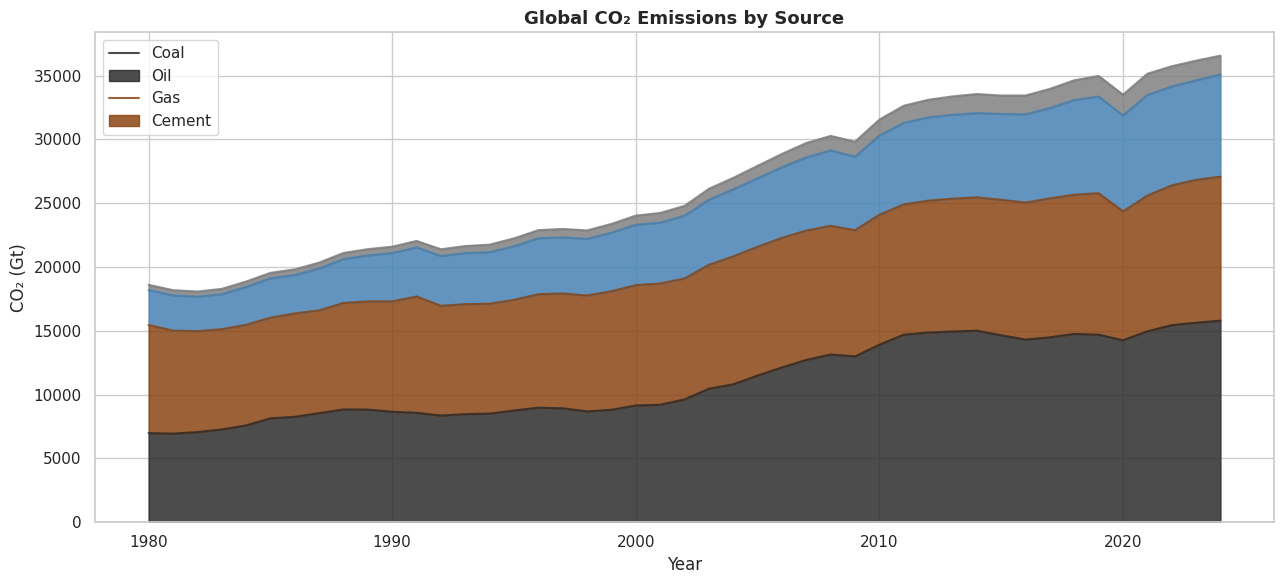

In [6]:
source_cols = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']
source_cols = [c for c in source_cols if c in owid.columns]

sources = owid.groupby('Year')[source_cols].sum()

fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#2c2c2c', '#8B4513', '#4682B4', '#808080']
sources.plot.area(ax=ax, color=colors[:len(source_cols)], alpha=0.85)
ax.set_title('Global CO₂ Emissions by Source', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ (Gt)')
ax.legend(labels=['Coal', 'Oil', 'Gas', 'Cement'][:len(source_cols)], loc='upper left')
plt.tight_layout()
plt.show()

---
## 7. Top 10 Emitters — Total & Per Capita

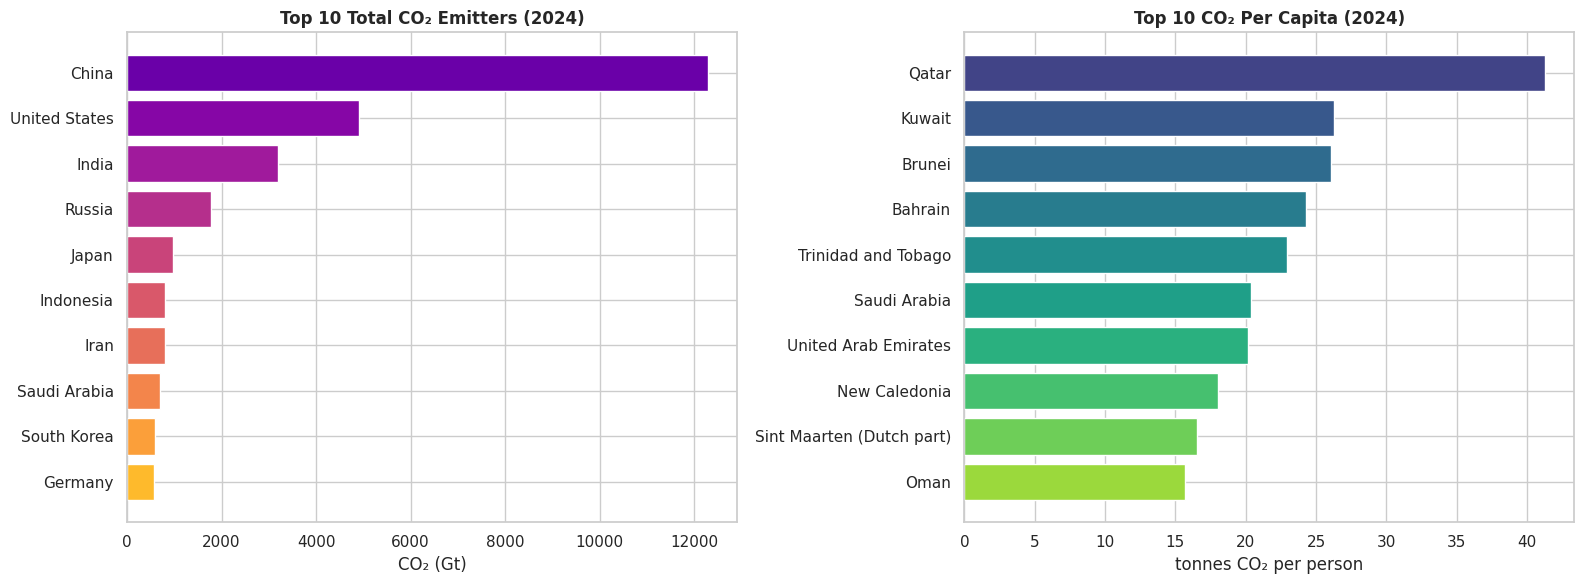

In [7]:
latest = owid[owid['Year'] == latest_year].dropna(subset=['co2'])
top10_total = latest.nlargest(10, 'co2')
top10_pc    = latest.dropna(subset=['co2_per_capita']).nlargest(10, 'co2_per_capita')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_t = plt.cm.plasma(np.linspace(0.2, 0.85, 10))
axes[0].barh(top10_total['Entity'], top10_total['co2'], color=colors_t)
axes[0].invert_yaxis()
axes[0].set_title(f'Top 10 Total CO₂ Emitters ({latest_year})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CO₂ (Gt)')

colors_p = plt.cm.viridis(np.linspace(0.2, 0.85, 10))
axes[1].barh(top10_pc['Entity'], top10_pc['co2_per_capita'], color=colors_p)
axes[1].invert_yaxis()
axes[1].set_title(f'Top 10 CO₂ Per Capita ({latest_year})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('tonnes CO₂ per person')

plt.tight_layout()
plt.show()

---
## 8. Regional Analysis — Who Warms Fastest vs Emits Least?

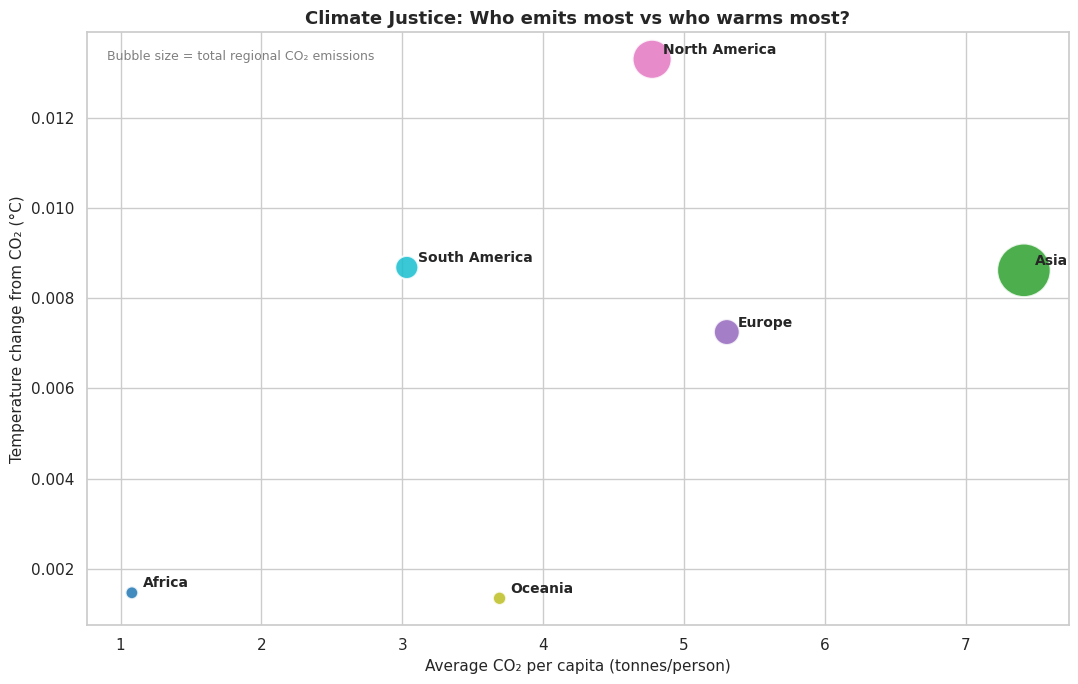

In [8]:
region_latest = (
    owid[(owid['Year'] == latest_year) & owid['region'].notna()]
    .groupby('region')[['co2_per_capita', 'temperature_change_from_co2', 'co2']]
    .mean()
    .reset_index()
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    region_latest['co2_per_capita'],
    region_latest['temperature_change_from_co2'],
    s=region_latest['co2'] * 3,
    c=range(len(region_latest)),
    cmap='tab10', alpha=0.85, edgecolors='white', linewidth=1.5
)
for _, row in region_latest.iterrows():
    ax.annotate(row['region'],
                (row['co2_per_capita'], row['temperature_change_from_co2']),
                fontsize=10, fontweight='bold',
                xytext=(8, 4), textcoords='offset points')
ax.set_xlabel('Average CO₂ per capita (tonnes/person)', fontsize=11)
ax.set_ylabel('Temperature change from CO₂ (°C)', fontsize=11)
ax.set_title('Climate Justice: Who emits most vs who warms most?', fontsize=13, fontweight='bold')
ax.text(0.02, 0.97, 'Bubble size = total regional CO₂ emissions',
        transform=ax.transAxes, fontsize=9, color='gray', va='top')
plt.tight_layout()
plt.show()

---
## 9. Correlation Analysis — CO₂, Temperature, Sea Level, Disasters

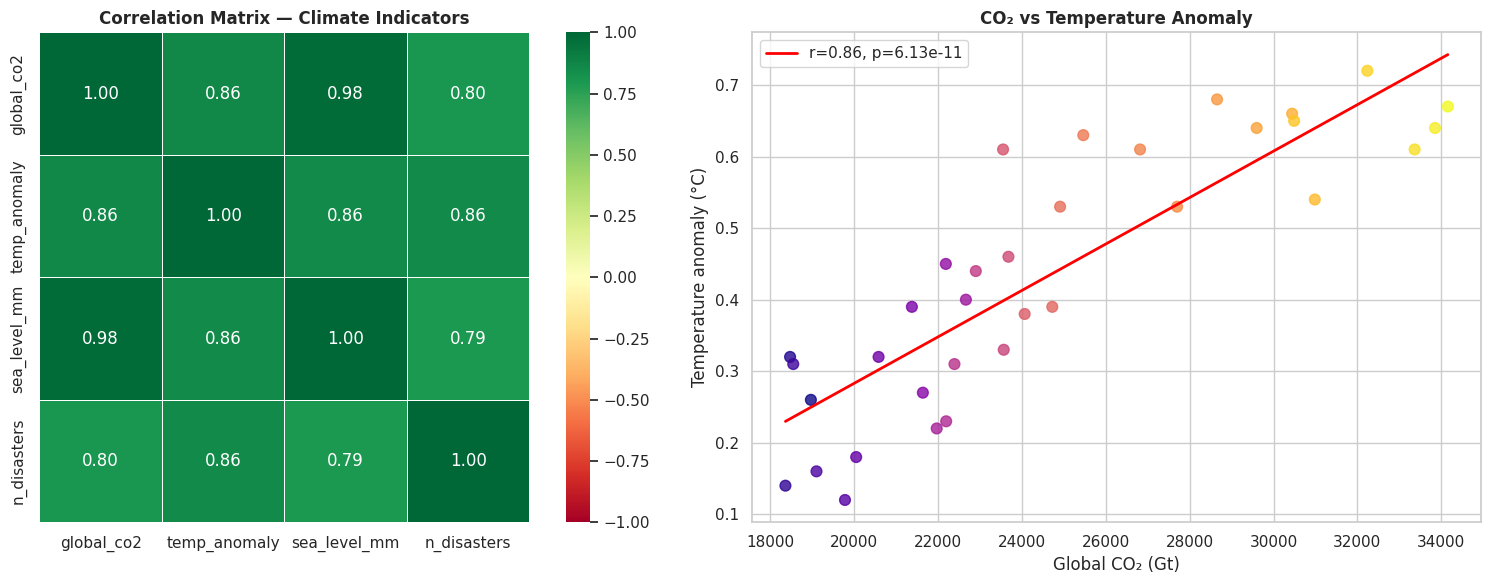

Correlation matrix:
              global_co2  temp_anomaly  sea_level_mm  n_disasters
global_co2         1.000         0.861         0.977        0.800
temp_anomaly       0.861         1.000         0.857        0.855
sea_level_mm       0.977         0.857         1.000        0.794
n_disasters        0.800         0.855         0.794        1.000


In [9]:
corr_cols = ['global_co2', 'temp_anomaly', 'sea_level_mm', 'n_disasters']
corr_cols = [c for c in corr_cols if c in global_df.columns]
corr_df = global_df[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5, square=True)
axes[0].set_title('Correlation Matrix — Climate Indicators', fontsize=12, fontweight='bold')

axes[1].scatter(corr_df['global_co2'], corr_df['temp_anomaly'],
                c=corr_df.index, cmap='plasma', s=60, alpha=0.8)
m, b, r, p, _ = stats.linregress(corr_df['global_co2'], corr_df['temp_anomaly'])
x_line = np.linspace(corr_df['global_co2'].min(), corr_df['global_co2'].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='red', linewidth=2,
             label=f'r={r:.2f}, p={p:.2e}')
axes[1].set_xlabel('Global CO₂ (Gt)')
axes[1].set_ylabel('Temperature anomaly (°C)')
axes[1].set_title('CO₂ vs Temperature Anomaly', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print('Correlation matrix:')
print(corr_matrix.round(3))

---
## 10. Decadal Temperature Comparison (Boxplots)

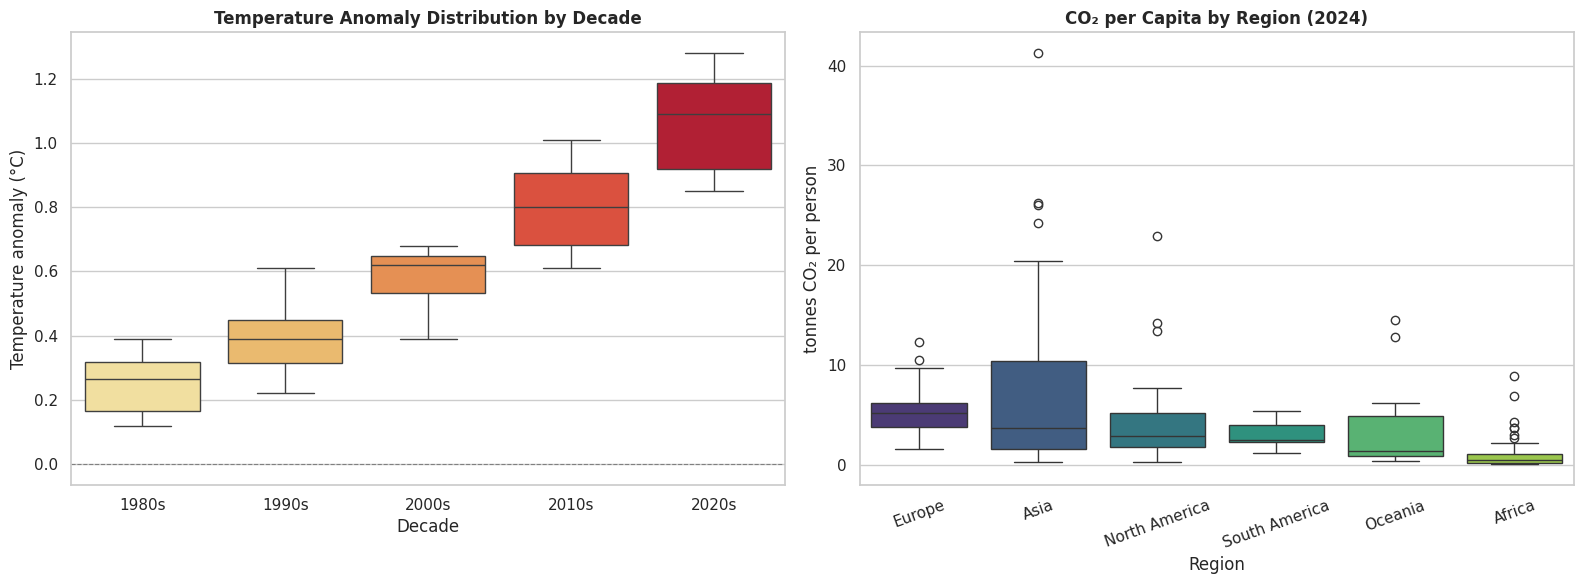

In [10]:
nasa['decade'] = (nasa['Year'] // 10 * 10).astype(str) + 's'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

decade_order = sorted(nasa['decade'].unique())
sns.boxplot(data=nasa, x='decade', y='temp_anomaly', order=decade_order,
            palette='YlOrRd', ax=axes[0])
axes[0].set_title('Temperature Anomaly Distribution by Decade', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Temperature anomaly (°C)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)

region_data = owid[(owid['Year'] == latest_year) & owid['region'].notna()].dropna(subset=['co2_per_capita'])
region_order_box = region_data.groupby('region')['co2_per_capita'].median().sort_values(ascending=False).index
sns.boxplot(data=region_data, x='region', y='co2_per_capita',
            order=region_order_box, palette='viridis', ax=axes[1])
axes[1].set_title(f'CO₂ per Capita by Region ({latest_year})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('tonnes CO₂ per person')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

---
## 11. Cumulative Emissions — Historical Responsibility

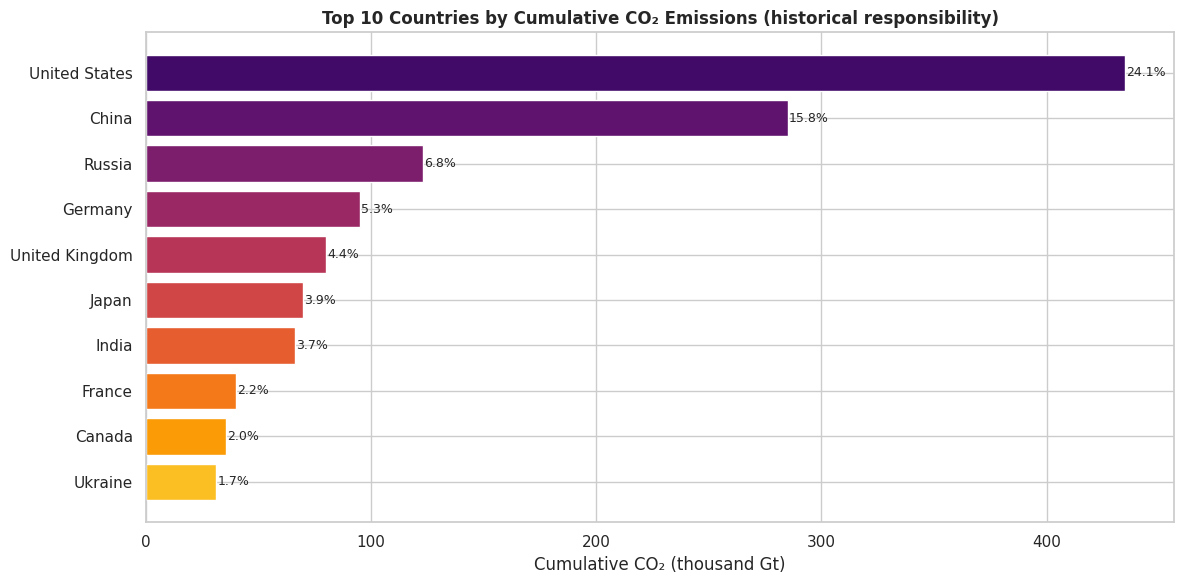

In [11]:
if 'cumulative_co2' in owid.columns:
    top10_cum = (
        owid[owid['Year'] == latest_year]
        .dropna(subset=['cumulative_co2'])
        .nlargest(10, 'cumulative_co2')
    )
    fig, ax = plt.subplots(figsize=(12, 6))
    colors_cum = plt.cm.inferno(np.linspace(0.2, 0.85, 10))
    bars = ax.barh(top10_cum['Entity'], top10_cum['cumulative_co2'] / 1e3, color=colors_cum)
    ax.invert_yaxis()
    ax.set_title('Top 10 Countries by Cumulative CO₂ Emissions (historical responsibility)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Cumulative CO₂ (thousand Gt)')
    total_world_cum = owid[owid['Year'] == latest_year]['cumulative_co2'].sum()
    for bar, (_, row) in zip(bars, top10_cum.iterrows()):
        pct = row['cumulative_co2'] / total_world_cum * 100
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 12. Tunisia Deep Dive

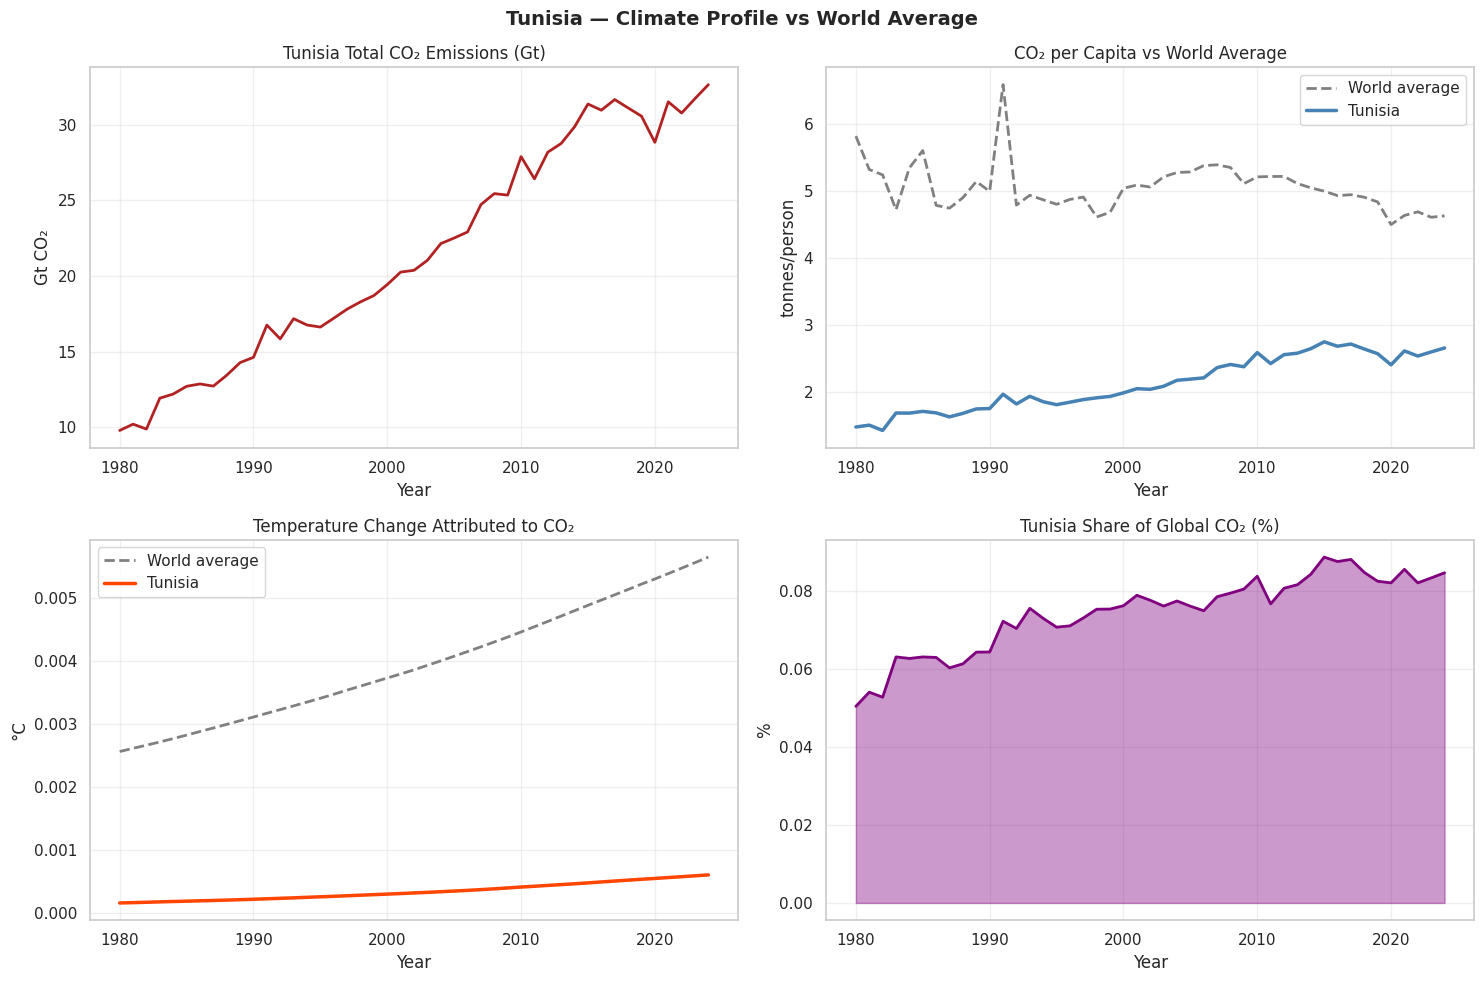

In [12]:
tun = owid[owid['Code'] == 'TUN'].sort_values('Year')
world_avg = owid.groupby('Year')[['co2_per_capita', 'temperature_change_from_co2']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tunisia — Climate Profile vs World Average', fontsize=14, fontweight='bold')

axes[0,0].plot(tun['Year'], tun['co2'], color='firebrick', linewidth=2)
axes[0,0].set_title('Tunisia Total CO₂ Emissions (Gt)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Gt CO₂')

axes[0,1].plot(world_avg['Year'], world_avg['co2_per_capita'],
               color='gray', linewidth=2, linestyle='--', label='World average')
axes[0,1].plot(tun['Year'], tun['co2_per_capita'],
               color='steelblue', linewidth=2.5, label='Tunisia')
axes[0,1].set_title('CO₂ per Capita vs World Average')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('tonnes/person')
axes[0,1].legend()

if 'temperature_change_from_co2' in tun.columns:
    axes[1,0].plot(world_avg['Year'], world_avg['temperature_change_from_co2'],
                   color='gray', linewidth=2, linestyle='--', label='World average')
    axes[1,0].plot(tun['Year'], tun['temperature_change_from_co2'],
                   color='orangered', linewidth=2.5, label='Tunisia')
    axes[1,0].set_title('Temperature Change Attributed to CO₂')
    axes[1,0].set_xlabel('Year')
    axes[1,0].set_ylabel('°C')
    axes[1,0].legend()

axes[1,1].fill_between(tun['Year'], tun['share_global_co2'], alpha=0.4, color='purple')
axes[1,1].plot(tun['Year'], tun['share_global_co2'], color='purple', linewidth=2)
axes[1,1].set_title('Tunisia Share of Global CO₂ (%)')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('%')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 13. CO₂ vs GDP — Is Economic Growth Always Carbon-Intensive?

Latest year with GDP data: 2022


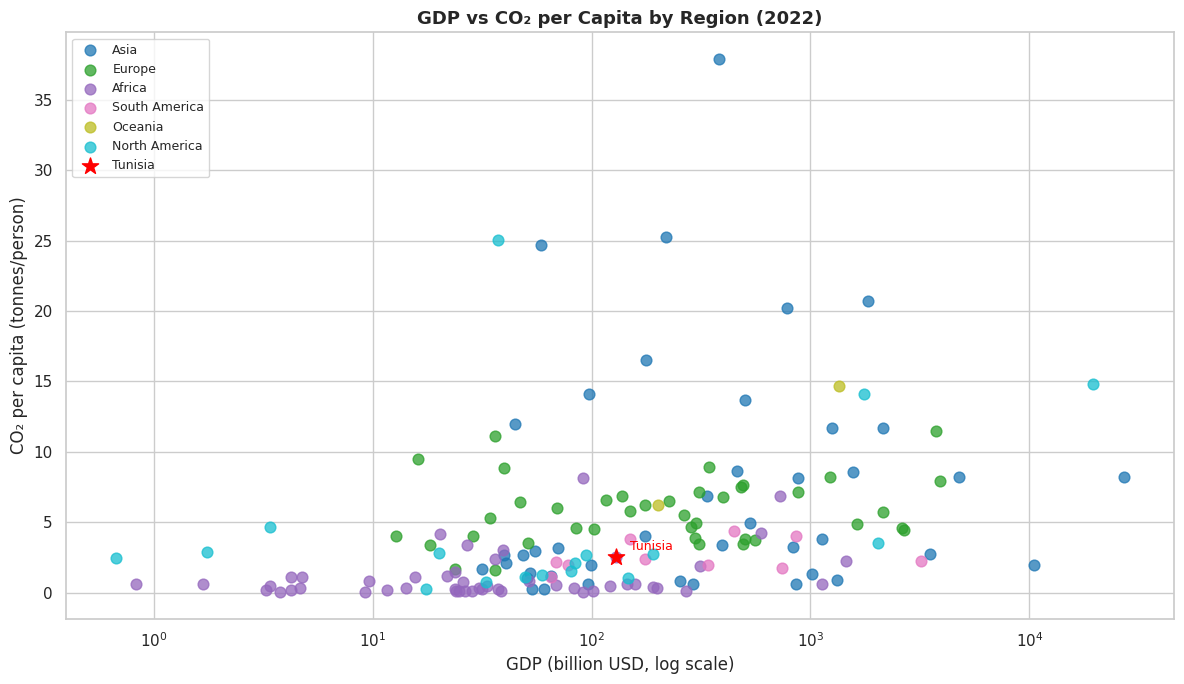

In [13]:
# Find the most recent year that actually has GDP data
gdp_data = owid.dropna(subset=['gdp', 'co2_per_capita', 'region'])
gdp_latest_year = int(gdp_data['Year'].max())
print(f'Latest year with GDP data: {gdp_latest_year}')

gdp_data = gdp_data[gdp_data['Year'] == gdp_latest_year]

fig, ax = plt.subplots(figsize=(12, 7))
regions = gdp_data['region'].unique()
colors_reg = plt.cm.tab10(np.linspace(0, 1, len(regions)))

for i, region in enumerate(regions):
    subset = gdp_data[gdp_data['region'] == region]
    ax.scatter(subset['gdp'] / 1e9, subset['co2_per_capita'],
               label=region, color=colors_reg[i], alpha=0.75, s=60)

tun_latest = gdp_data[gdp_data['Code'] == 'TUN']
if len(tun_latest) > 0:
    ax.scatter(tun_latest['gdp']/1e9, tun_latest['co2_per_capita'],
               color='red', s=150, zorder=5, marker='*', label='Tunisia')
    ax.annotate('Tunisia', (tun_latest['gdp'].values[0]/1e9, tun_latest['co2_per_capita'].values[0]),
                xytext=(10, 5), textcoords='offset points', fontsize=9, color='red')

ax.set_xscale('log')
ax.set_xlabel('GDP (billion USD, log scale)')
ax.set_ylabel('CO₂ per capita (tonnes/person)')
ax.set_title(f'GDP vs CO₂ per Capita by Region ({gdp_latest_year})', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 14. Key Statistical Insights Summary

In [14]:
print('=' * 60)
print('KEY FINDINGS SUMMARY')
print('=' * 60)

g1980 = global_co2[global_co2['Year'] == 1980]['co2'].values[0]
g_last = global_co2[global_co2['Year'] == latest_year]['co2'].values[0]
print(f'\n🌍 Global CO₂: 1980={g1980:.1f}Gt → {latest_year}={g_last:.1f}Gt (+{(g_last-g1980)/g1980*100:.0f}%)')
print(f'🌡️  Warming trend: +{slope*10:.3f}°C/decade  |  R²={r**2:.3f}')
print(f'🌊 Sea level total rise: {total_rise:.1f} mm  |  rate: +{slope_sea:.2f} mm/year')

if 'global_co2' in corr_matrix.columns and 'temp_anomaly' in corr_matrix.columns:
    print(f'📊 Correlation CO₂ ↔ Temperature: r = {corr_matrix.loc["global_co2", "temp_anomaly"]:.3f}')

tun_pc = tun[tun['Year'] == latest_year]['co2_per_capita']
world_pc = world_avg[world_avg['Year'] == latest_year]['co2_per_capita']
if len(tun_pc) > 0 and len(world_pc) > 0:
    print(f'🇹🇳 Tunisia: {tun_pc.values[0]:.2f} t/person vs world avg {world_pc.values[0]:.2f} t/person')
    print(f'   → Tunisia emits {world_pc.values[0]/tun_pc.values[0]:.1f}x LESS than world average per capita')

print('\n' + '=' * 60)

KEY FINDINGS SUMMARY

🌍 Global CO₂: 1980=18965.5Gt → 2024=37398.1Gt (+97%)
🌡️  Warming trend: +0.208°C/decade  |  R²=0.742
🌊 Sea level total rise: 9.7 mm  |  rate: +0.06 mm/year
📊 Correlation CO₂ ↔ Temperature: r = 0.861
🇹🇳 Tunisia: 2.66 t/person vs world avg 4.63 t/person
   → Tunisia emits 1.7x LESS than world average per capita

